In [1]:
from itertools import product
import pickle
import json
import h5py
from tqdm import tqdm, trange

import numpy as np
from numpy.linalg import eigh
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Ellipse
from corner import corner as corner_plot

from scipy import special, stats
from scipy.stats import gaussian_kde, chi2
from scipy.interpolate import RegularGridInterpolator

import os

from local_utils import delaunaytor
from popsummary.popresult import PopulationResult
from astropy.cosmology import Planck15
from astropy import units as u


plt.style.use("tableau-colorblind10")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14
plt.rcParams["text.usetex"] = True

In [2]:
def q_flat(x):
    ans=1/(5-(-15))

    return ans


def kl_divergence_kde_p_known_q(p_samples, q_pdf, base=np.e, bandwidth='scott'):
    """
    Estimate KL divergence D_KL(P || Q) where:
      - P is only known via samples (estimated with KDE)
      - Q is known analytically via q_pdf(x)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_pdf (function): function that returns q(x) given x
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated KL divergence D_KL(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde = gaussian_kde(p_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde(p_samples)
    q_vals = q_pdf(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_vals = np.clip(q_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_vals)
    kl = np.mean(log_ratio)

    return kl / np.log(base)


def kl_divergence_kde(p_samples, q_samples, base=np.e, bandwidth='scott'):
    """
    Estimate delta divergence D_delta(P || Q) where:
      - P is known via samples (estimated with KDE)
      - Q is known via samples (estimated with KDE)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_samples (array): 1D array of samples from Q
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated delta divergence D_delta(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde_p = gaussian_kde(p_samples, bw_method=bandwidth)

    q_samples = np.asarray(q_samples)
    kde_q = gaussian_kde(q_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde_p(p_samples)
    q_kde_vals = kde_q(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_kde_vals = np.clip(q_kde_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_kde_vals)
    delta = np.mean(log_ratio)

    return delta / np.log(base)

In [3]:
def power_law_peak(m1, gaussian_params, powlaw_params, smooth_params):
    gauss_pdf = stats.norm(
            loc=gaussian_params[1], scale=gaussian_params[2]
        ).pdf(m1)

    indx, lower, upper = powlaw_params
    out_bounds = np.logical_or(m1 < lower, m1 > upper)
    norm = (upper**(1 - indx) - lower**(1 - indx)) / (1 - indx)

    powlaw_pdf = m1**(-indx) / norm

    weight = gaussian_params[0]
    result = weight * gauss_pdf + (1 - weight) * powlaw_pdf

    sig = smooth_params[0]
    smooth = np.zeros_like(m1)
    in_smooth = np.logical_or(m1 >= lower, m1 < lower+sig)
    f = lambda m: np.exp(sig/m + sig/(m-sig))
    smooth[in_smooth] = 1 /(f(m1-lower)+1)
    smooth[m1>=lower+sig]=1

    return np.where(out_bounds, 0, result*smooth)

def massratio_pdf(q, m1, powlaw_params_q, smooth_params):
    indx, lower, upper = powlaw_params_q
    out_bounds = np.logical_or(m1 < lower, m1 > upper)
    norm = (upper**(1 - indx) - lower**(1 - indx)) / (1 - indx)

    powlaw_pdf = q**indx /norm

    sig = smooth_params[0]
    smooth = np.zeros((len(m1),len(q)))
    in_smooth = np.logical_and(m1 >= lower, m1 < lower+sig)
    f = lambda m: np.exp(sig/m + sig/(m-sig))
    smooth[in_smooth] = 1 /(f(mass_ratio * m1[in_smooth,None]-lower)+1)
    smooth[m1>=lower+sig]=1

    return powlaw_pdf * smooth

def q_prior(q, m1, beta_q, m_min):
    out_bounds = q * m1 < m_min
    normalisation = (beta_q + 1) / (1 - (m_min / m1) ** (beta_q + 1))
    p_of_q = normalisation * q**beta_q
    return np.where(out_bounds, 0, p_of_q)

def simple_massratio_pdf(q, beta_q):
    norm = (1 + beta_q) /(1 - 0.1**(1+beta_q))
    return q**beta_q *norm

## Use LVK population analysis results as `true' population

In [4]:
gwtc3 = '/home/tristan-bruel/Documents/Science/LVK/gwtc3'
zeval = 0.
color_plpeak = "#1f78b4"

O3_only_PPD = os.path.join(gwtc3,'analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_mass_data.h5')

mass_1_gwtc3 = np.linspace(2, 100, 1000)
mass_ratio_gwtc3 = np.linspace(0.1, 1, 500)
with h5py.File(O3_only_PPD, "r") as f:
    mass_ppd = f["ppd"]
    mass_lines = f["lines"]
    mass_1_ppd = np.trapezoid(y=mass_ppd, x=mass_ratio_gwtc3, axis=0)
    mass_r_ppd = np.trapezoid(y=mass_ppd, x=mass_1_gwtc3, axis=-1)
    mass_1_lower = np.percentile(mass_lines["mass_1"], 5, axis=0)
    mass_1_upper = np.percentile(mass_lines["mass_1"], 95, axis=0)
    mass_r_lower = np.percentile(mass_lines["mass_ratio"], 5, axis=0)
    mass_r_upper = np.percentile(mass_lines["mass_ratio"], 95, axis=0)

In [5]:
tf = os.path.join(gwtc3,"analyses/PowerLawPeak/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_result.json")
with open(tf) as jf:
    data = json.load(jf)['posterior']['content']
kappas_gwtc3 = np.array(data['lamb'])
R0_gwtc3 = np.array(data['rate'])
# Power-law + Peak mass model parameters
lambdas = np.array(data['lam'])
mu_m = np.array(data['mpp'])
sigma_m = np.array(data['sigpp'])
gaussian_params = np.vstack([lambdas, mu_m, sigma_m]).T
alphas = np.array(data['alpha'])
mmin = np.array(data['mmin'])
mmax = np.array(data['mmax'])
powlaw_params = np.vstack([alphas, mmin, mmax]).T
delta_m = np.array(data['delta_m'])
smooth_params = np.vstack([delta_m]).T

# Downselect to a reasonable number of hyperparameter samples
inds = np.random.choice(np.arange(R0_gwtc3.size),size=1000,replace=False)

# Define a grid of redshifts, and prepare corresponding arrays to hold R(z)
zs_gwtc3 = np.linspace(0,1.5,100)
Rz_gwtc3 = np.zeros((inds.size,zs_gwtc3.size))
dRdm1_gwtc3 = np.zeros((inds.size,mass_1_gwtc3.size))
# For each of our randomly selected samples, compute and save R(z)
for i,ind in enumerate(inds):
    Rz_gwtc3[i,:] = R0_gwtc3[ind]*(1.+zs_gwtc3)**kappas_gwtc3[ind]
    Rnorm = R0_gwtc3[ind]
    #indx, lower, upper = powlaw_params[ind]
    #in_bounds = np.logical_and(mass_1_gwtc3 >= lower, mass_1_gwtc3 < upper)
    m1_pdf = power_law_peak(mass_1_gwtc3, gaussian_params[ind], powlaw_params[ind], smooth_params[ind])
    #norm = np.trapezoid(x=mass_1_gwtc3[in_bounds], y=m1_pdf[in_bounds])
    norm = np.trapezoid(x=mass_1_gwtc3, y=m1_pdf)
    dRdm1_gwtc3[i,:] = Rnorm * m1_pdf /norm

/tmp/ipykernel_152263/3058028465.py:18: RuntimeWarning: overflow encountered in exp
  f = lambda m: np.exp(sig/m + sig/(m-sig))


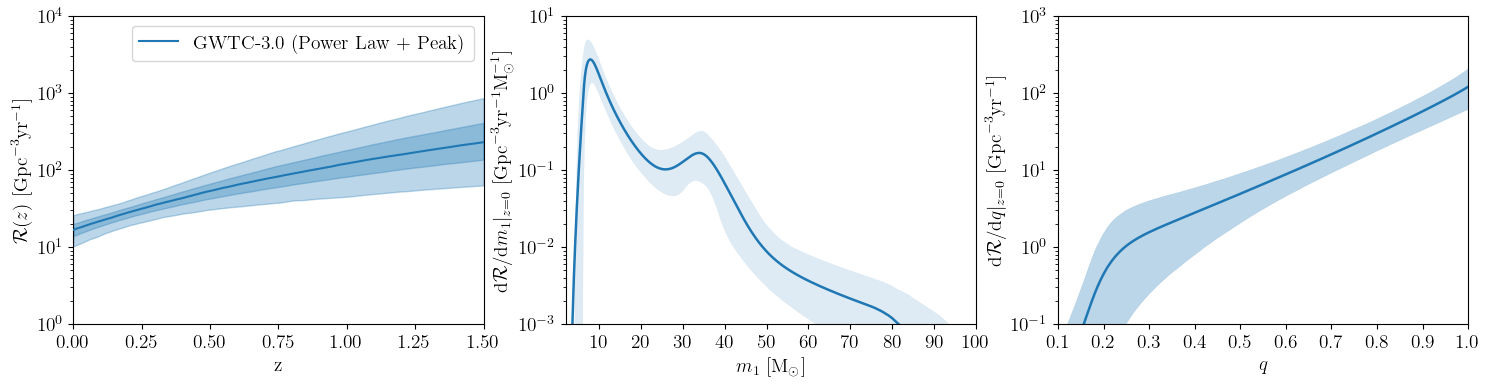

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))

# Merger rate with redshift #
ax = axes[0]
ax.plot(zs_gwtc3, np.median(Rz_gwtc3,axis=0),
        color=color_plpeak, lw=1.5, zorder=5,
        label='GWTC-3.0 (Power Law + Peak)',
       )
ax.fill_between(zs_gwtc3,
        np.quantile(Rz_gwtc3,0.05,axis=0),
        np.quantile(Rz_gwtc3, 0.95, axis=0),
        color=color_plpeak, alpha=0.3)
ax.fill_between(zs_gwtc3,
        np.quantile(Rz_gwtc3,0.25,axis=0),
        np.quantile(Rz_gwtc3, 0.75, axis=0),
        color=color_plpeak, alpha=0.3)

ax.set_xlabel('z')
ax.set_xlim(xmin=0, xmax=1.5)
ax.set_ylabel(r'$\mathcal{R}(z)\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1, ymax=1e4)
ax.legend()

# Primary mass #
ax = axes[1]
ax.plot(mass_1_gwtc3, mass_1_ppd,
        color=color_plpeak, lw=1.8, zorder=1)
ax.fill_between(mass_1_gwtc3,
        mass_1_lower,
        mass_1_upper,
        color=color_plpeak, lw=0.2, alpha=0.14, zorder=0)
ax.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
ax.set_xlim(xmin=2., xmax=100.)
ax.set_xticks(np.linspace(10,100,10))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1 |_{z=0}\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1} \mathrm{M}_\odot^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=1e-3, ymax=10)
# ax.plot(mass_1_gwtc3, np.median(dRdm1_gwtc3,axis=0),
#         color='r', lw=1.5, zorder=5,
#        )
# ax.fill_between(mass_1_gwtc3,
#         np.quantile(dRdm1_gwtc3,0.05,axis=0),
#         np.quantile(dRdm1_gwtc3, 0.95, axis=0),
#         color='r', alpha=0.3)

# Mass ratio #
ax = axes[2]
ax.plot(mass_ratio_gwtc3, mass_r_ppd,
        color=color_plpeak, lw=1.8, zorder=1)
ax.fill_between(mass_ratio_gwtc3,
        mass_r_lower,
        mass_r_upper,
        color=color_plpeak, lw=0.2, alpha=0.3, zorder=0)
ax.set_xlabel(r'$q$')
ax.set_xlim(xmin=0.1, xmax=1)
ax.set_xticks(np.linspace(0.1,1,10))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}q |_{z=0}\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=0.1, ymax=1e3)
# ax.plot(mass_ratio_gwtc3, np.median(dRdq_gwtc3,axis=0),
#         color='r', lw=1.5, zorder=5,
#        )
# ax.fill_between(mass_ratio_gwtc3,
#         np.quantile(dRdq_gwtc3,0.05,axis=0),
#         np.quantile(dRdq_gwtc3, 0.95, axis=0),
#         color='r', alpha=0.3)

plt.show()
plt.close()

In [7]:
num_pop_LVK = 1_000
selected_pop_LVK = np.random.choice(R0_gwtc3.size, size=num_pop_LVK, replace=False)

## GW events

In [8]:
parameter_keys = ["m1", "z", "q", "chi1", "chi2", "tilt1", "tilt2"]

data_file = np.load("./lvc_data_lvc_samples_full.npz")
observed_events = np.vstack([data_file[key + "s"] for key in parameter_keys]).T
num_events = data_file["nevents"][0]
num_samples = data_file["nsamples"][0]
event_priors = data_file["priors"]
print(
        f"Running with {num_events} events × {num_samples} samples = {num_events*num_samples} total samples"
    )

event_barycenters = observed_events.reshape(
    (num_events, num_samples, observed_events.shape[-1])
).mean(axis=1)

Running with 69 events × 4278 samples = 295182 total samples


## Triangulation setup

In [9]:
z_min = 1e-6
z_max = 1.5
m1_min = 3.0
m1_max = 100.0 + 1e-6

w_min = -20
w_max = 15
nvertices_min = 4
nvertices_max = 100

corners = np.array([ 
        [m1_min, z_min],
        [m1_min, z_max],
        [m1_max, z_min],
        [m1_max, z_max], 
    ])

print(corners)

[[3.00000000e+00 1.00000000e-06]
 [3.00000000e+00 1.50000000e+00]
 [1.00000001e+02 1.00000000e-06]
 [1.00000001e+02 1.50000000e+00]]


## Some diagnostics of the sampling

In [10]:
backend_file = 'outdir0/backend'
with open(backend_file, "rb") as f:
    back = pickle.load(f)
ntemps = back.ntemps
nwalkers = back.nwalkers
nsteps = back.chain['tri'].shape[0]
tri_sizes = np.array([
        back.inds["tri"][step, 0, walker].sum()
        for step, walker in product(range(nsteps), range(nwalkers))
        ])

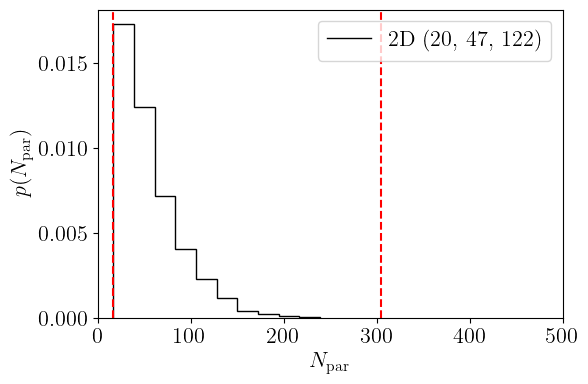

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
ax.set(
    yscale="linear",
    xlabel=r"$N_{\mathrm{par}}$",
    ylabel=r"$p(N_{\mathrm{par}})$",
    xlim=(0, 500),
)

ls = ["-", "--", ":"]

ind=0
ndim=2
offset = 2**ndim

n_params = tri_sizes * (ndim + 1) + 2**ndim + 1

l, m, h = np.quantile(n_params, [0.05, 0.5, 0.95]).astype(int)

hist, edges = np.histogram(n_params, density=True)
ax.stairs(
    hist,
    edges, 
    color='black', 
    ls=ls[ind], 
    label=f"{ndim}D ({l}, {m}, {h})"
)

ax.axvline(nvertices_min * (ndim + 1) + 2**ndim + 1, color='r', linestyle='--')
ax.axvline(nvertices_max * (ndim + 1) + 2**ndim + 1, color='r', linestyle='--')

ax.legend()
plt.show()
plt.close()

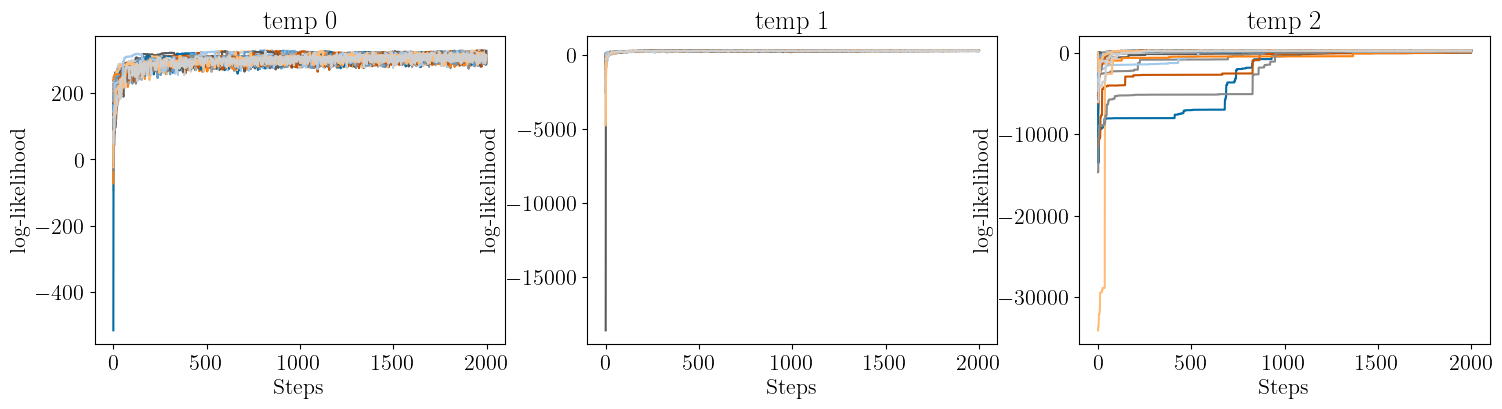

In [12]:
fig, axes = plt.subplots(1, ntemps, figsize=(18,4))
for t,w in product(range(ntemps),range(nwalkers)):
    ax = axes[t]
    ax.plot(back.get_log_like()[:, t, w])
    ax.set(title=f"temp {t}")
    ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-likelihood")
plt.show()
plt.close()

In [13]:
nburn = 1_000

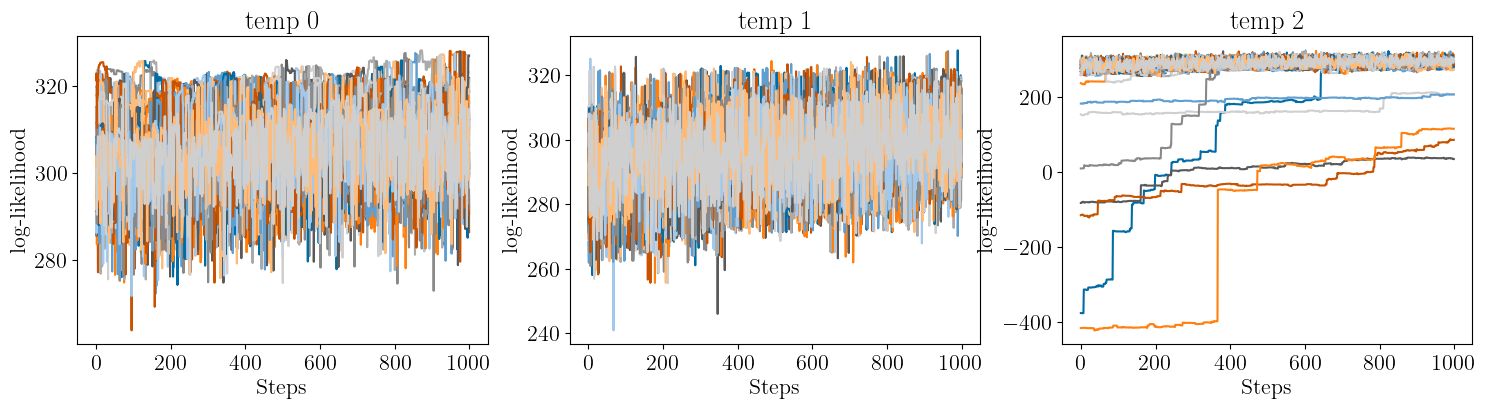

In [14]:
fig, axes = plt.subplots(1, ntemps, figsize=(18,4))
for t,w in product(range(ntemps),range(nwalkers)):
    ax = axes[t]
    ax.plot(back.get_log_like()[nburn:, t, w])
    ax.set(title=f"temp {t}")
    ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-likelihood")
plt.show()
plt.close()

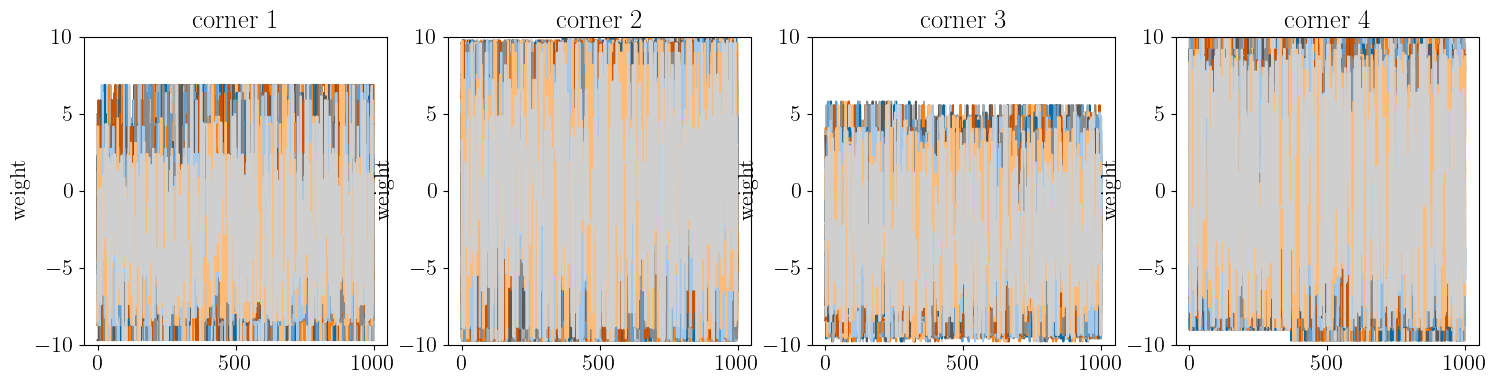

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for n in range(len(corners)):
    ax = axes[n]
    # for t,w in product(range(ntemps),range(nwalkers)):
    #     ax.plot(np.ravel(back.chain['corner_w'][nburn:,t,w,0,n]))
    t=0
    for w in range(nwalkers):
        ax.plot(np.ravel(back.chain['corner_w'][nburn:,t,w,0,n]))
    ax.set(title=f"corner {n+1}")
    #ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"weight")
    ax.set_ylim(w_min,w_max)
plt.show()
plt.close()

## Load triangulations

In [16]:
all_triangulations = []
# for t in range(ntemps):
#     triangulations = [
#         back.chain["tri"][step, t, walker][back.inds["tri"][step, t, walker]]
#         for step, walker in product(range(nburn,nsteps), range(nwalkers))
#     ]
#     corner_weights = np.array(
#         [
#             back.chain["corner_w"][step, t, walker]
#             for step, walker in product(range(nburn,nsteps), range(nwalkers))
#         ]
#     )
#     for ind in tqdm(range(len(triangulations))):
#         all_triangulations.extend([
#             np.vstack([triangulations[ind], np.c_[corners, corner_weights[ind].T]])                
#         ])
### KEEP ONLY FIRST TEMPERATURE FOR NOW ###
t=0
triangulations = [
    back.chain["tri"][step, t, walker][back.inds["tri"][step, t, walker]]
    for step, walker in product(range(nburn,nsteps), range(nwalkers))
]
corner_weights = np.array(
    [
        back.chain["corner_w"][step, t, walker]
        for step, walker in product(range(nburn,nsteps), range(nwalkers))
    ]
)
for ind in tqdm(range(len(triangulations))):
    all_triangulations.extend([
        np.vstack([triangulations[ind], np.c_[corners, corner_weights[ind].T]])                
    ])

100%|████████████████████████████████| 40000/40000 [00:00<00:00, 215534.08it/s]


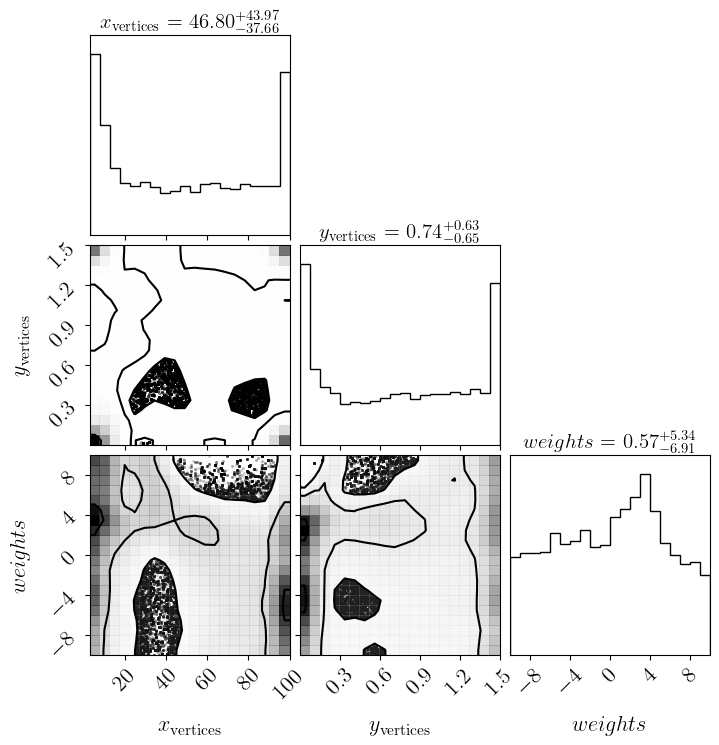

In [17]:
ws = np.hstack([tri[:, -1] for tri in all_triangulations])
vertices = np.vstack([tri[:, :-1] for tri in all_triangulations])    
corner_plot(np.c_[vertices, ws], smooth=True, levels=[0.05, 0.5, 0.95],
            labels=[r"$x_\mathrm{vertices}$", r"$y_\mathrm{vertices}$", r"$weights$"],
            show_titles=True,
            title_kwargs={"fontsize": 15},
           )
plt.show()
plt.close()

In [18]:
## Evolution of the inferred rate at a fixed point ##
targets = np.array([[10.,0.2],[35.,0.2],[10.,1.0],[35.,1.0]])
selected_tris = np.random.choice(len(all_triangulations), size=1000, replace=False)
num_triangulations = len(selected_tris)

log_rate_at_target = np.zeros((num_triangulations,4))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_at_target[ind] = this_delo.interpolate(targets)

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 6285.31it/s]


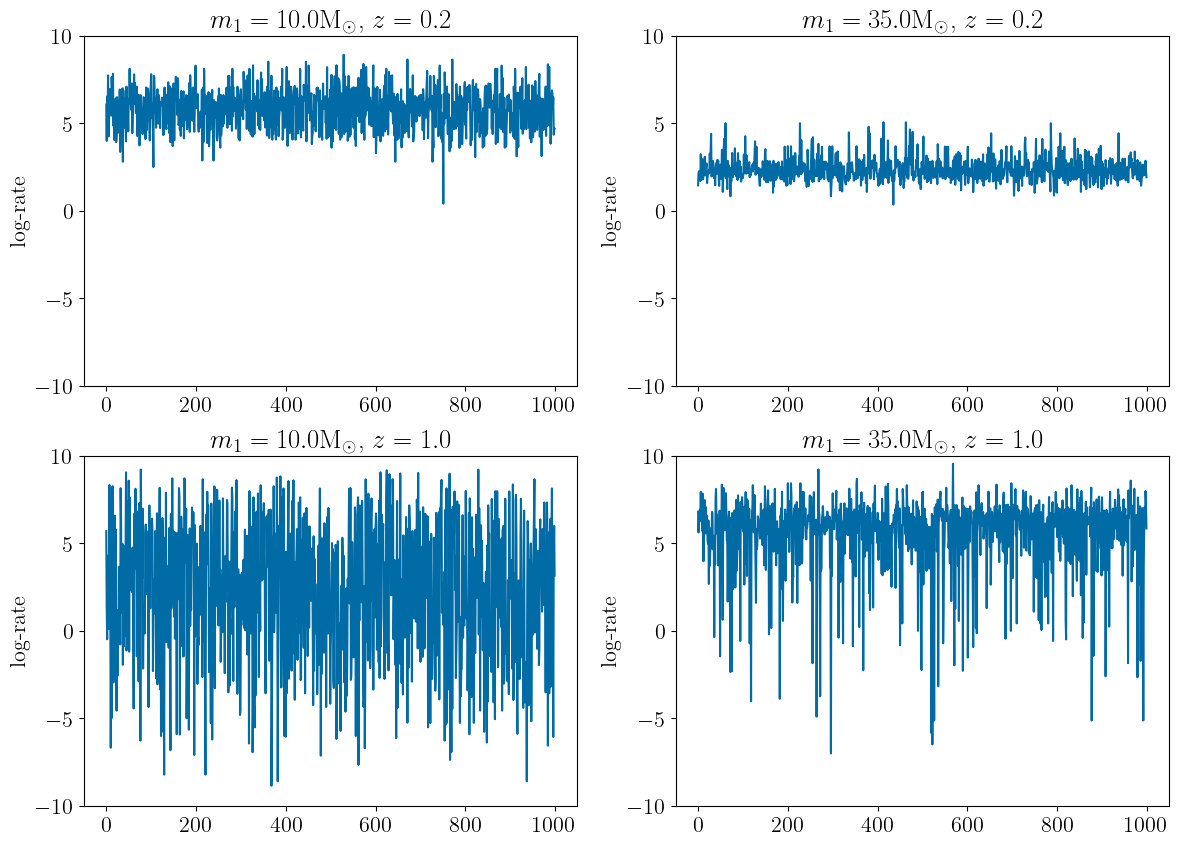

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for n in range(len(targets)):
    ax = axes[n//2, n%2]
    ax.plot(log_rate_at_target[:,n])
    ax.set(title=r"$m_1=%.1f\mathrm{M}_\odot$, $z=%.1f$"
           %(targets[n][0],targets[n][1]))
    #ax.set_xlabel(r"Steps")
    ax.set_ylabel(r"log-rate")
    ax.set_ylim(w_min,w_max)
plt.show()
plt.close()

## Compute rate over grids

In [20]:
Tobs = 66997600.0 /(24 * 3600 * 365.25) # in years

In [21]:
m1_grid = np.linspace(m1_min, m1_max, 49)
z_grid = np.linspace(0.05, z_max, 50)

X, Y = np.meshgrid(m1_grid, z_grid)
grid = np.c_[X.ravel(), Y.ravel()]

dm1 = m1_grid[1] - m1_grid[0]
dz = z_grid[1] - z_grid[0]

to_comoving_volume = (1 + z_grid) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid).to(u.Gpc**3 / u.sr).value
    )

In [22]:
# selected_tris = range(0, len(all_triangulations), 40)
selected_tris = np.random.choice(len(all_triangulations), size=1000, replace=False)
num_triangulations = len(selected_tris)

log_rate = np.zeros((num_triangulations, grid.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate[ind] = this_delo.interpolate(grid)
    
square_rate = log_rate.reshape(num_triangulations, z_grid.shape[0], m1_grid.shape[0])

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 2330.05it/s]


In [23]:
median = np.quantile(square_rate, 0.5, axis=0)
low = np.quantile(square_rate, 0.05, axis=0)
high = np.quantile(square_rate, 0.95, axis=0)

### Injections

In [24]:
injections_file = np.load("./selection_function_elements.npz")
detected_injections = np.vstack(
    [injections_file[key + "s"] for key in parameter_keys]
).T
injection_priors = injections_file["inj_priors"]
num_injections = injections_file["ninjs"]

## Prior

In [25]:
nsamples_prior = 1_000
log_rate_prior = np.zeros((nsamples_prior, grid.shape[0]))

for i in tqdm(range(nsamples_prior)):
    nleaves_i = np.random.randint(nvertices_min, nvertices_max)
    tri_i = np.zeros((nleaves_i+offset,ndim+1))
    tri_i[:offset,:-1] = corners
    tri_i[offset:,0] = np.random.uniform(m1_min, m1_max, nleaves_i)
    tri_i[offset:,1] = np.random.uniform(z_min, z_max, nleaves_i)
    tri_i[:,-1] = np.random.uniform(w_min, w_max, nleaves_i+offset)
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior[i] = this_delo.interpolate(grid)

square_rate_prior = log_rate_prior.reshape(nsamples_prior, z_grid.shape[0], m1_grid.shape[0])

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 1567.84it/s]


In [26]:
Nevents_prior = np.sum(np.exp(square_rate_prior) *to_comoving_volume[None,:,None], axis=(1,2)) *dm1 *dz
median_prior = np.quantile(Nevents_prior, 0.5)
low_prior = np.quantile(Nevents_prior, 0.05)
high_prior = np.quantile(Nevents_prior, 0.95)

# Marginals

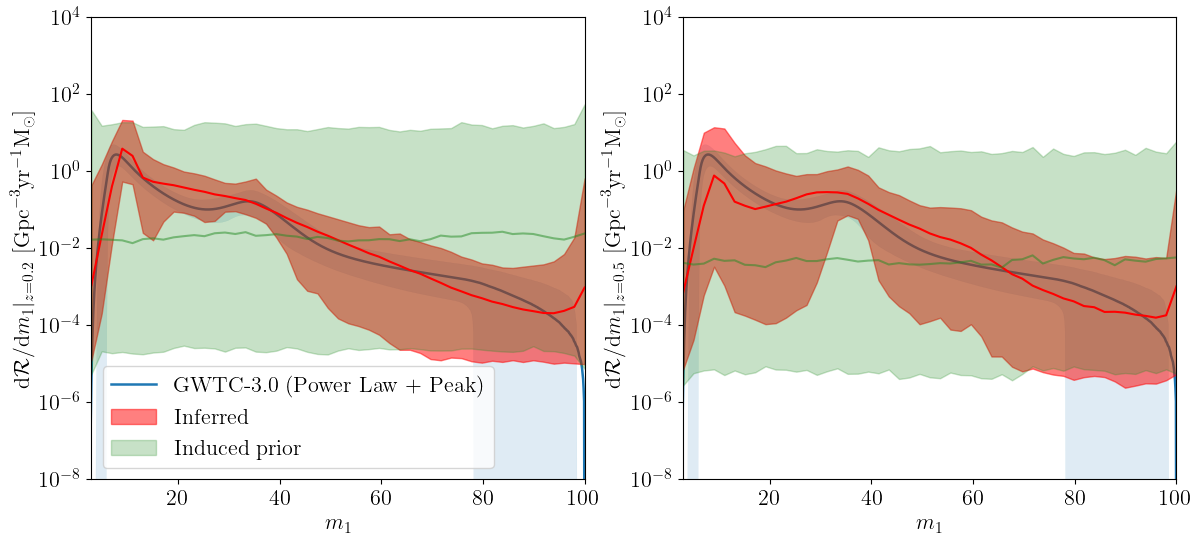

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

z_values_toplot = [0.2,1.0]
ymins = [1e-8, 1e-8]
ymaxs = [1e4, 1e4]

for n,zeval in enumerate([0.2,0.5]):
    ax = axes[n]
    zeval_ind = np.argmin(np.abs(z_grid-zeval))

    ax.plot(mass_1_gwtc3, mass_1_ppd,
            color=color_plpeak, lw=1.8, zorder=1,
            label='GWTC-3.0 (Power Law + Peak)',
           )
    ax.fill_between(mass_1_gwtc3,
            mass_1_lower,
            mass_1_upper,
            color=color_plpeak, lw=0.2, alpha=0.14, zorder=0)
    
    dRdm1_zeval = np.exp(square_rate[:,zeval_ind,:]) *to_comoving_volume[zeval_ind]
    low_dRdm1 = np.quantile(dRdm1_zeval, 0.05, axis=0)
    median_dRdm1 = np.quantile(dRdm1_zeval, 0.5, axis=0)
    high_dRdm1 = np.quantile(dRdm1_zeval, 0.95, axis=0)
    
    ax.plot(m1_grid, median_dRdm1, color="r")
    ax.fill_between(m1_grid, low_dRdm1, high_dRdm1,
                    color="r", alpha=0.5,
                    label=r'Inferred',
                    )

    dRdm1_prior_zeval = np.exp(square_rate_prior[:,zeval_ind,:]) *to_comoving_volume[zeval_ind]
    low_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.05, axis=0)
    median_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.5, axis=0)
    high_dRdm1_prior = np.quantile(dRdm1_prior_zeval, 0.95, axis=0)
    ax.plot(m1_grid, median_dRdm1_prior, color="forestgreen", alpha=0.5)
    ax.fill_between(m1_grid, low_dRdm1_prior, high_dRdm1_prior,
                    color="forestgreen", alpha=0.25,
                    label='Induced prior',
                    )
    
    ax.set_xlabel(r'$m_1$')
    ax.set_xlim(xmin=m1_grid.min(), xmax=m1_grid.max())
    ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}m_1 |_{z=%.1f}\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}\mathrm{M}_\odot]$' %zeval)
    ax.set_yscale('log')
    #ax.set_box_aspect(1)
    ax.set_ylim(ymin=ymins[n], ymax=ymaxs[n])

axes[0].legend(loc='best')
plt.show()
plt.close()

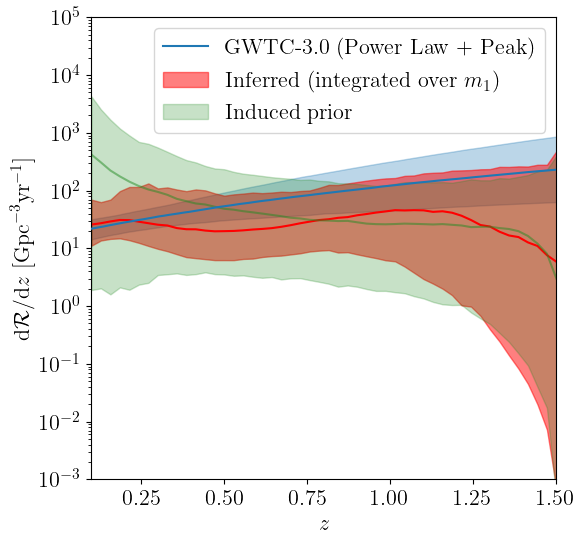

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.plot(zs_gwtc3, np.median(Rz_gwtc3,axis=0),
        color=color_plpeak, lw=1.5, zorder=5,
        label='GWTC-3.0 (Power Law + Peak)',
       )
ax.fill_between(zs_gwtc3,
        np.quantile(Rz_gwtc3,0.05,axis=0),
        np.quantile(Rz_gwtc3, 0.95, axis=0),
        color=color_plpeak, alpha=0.3)

dRdz = np.sum(np.exp(square_rate) 
              *to_comoving_volume[None,:,None], axis=2) *dm1
low_dRdz = np.quantile(dRdz, 0.05, axis=0)
median_dRdz = np.quantile(dRdz, 0.5, axis=0)
high_dRdz = np.quantile(dRdz, 0.95, axis=0)

ax.plot(z_grid, median_dRdz, color="r")
ax.fill_between(z_grid, low_dRdz, high_dRdz,
                color="r", alpha=0.5,
                label=r'Inferred (integrated over $m_1$)',
                )

dRdz_prior = np.sum(np.exp(square_rate_prior) 
                    *to_comoving_volume[None,:,None], axis=2) *dm1
low_dRdz_prior = np.quantile(dRdz_prior, 0.05, axis=0)
median_dRdz_prior = np.quantile(dRdz_prior, 0.5, axis=0)
high_dRdz_prior = np.quantile(dRdz_prior, 0.95, axis=0)
ax.plot(z_grid, median_dRdz_prior, color="forestgreen", alpha=0.5)
ax.fill_between(z_grid, low_dRdz_prior, high_dRdz_prior,
                color="forestgreen", alpha=0.25,
                label='Induced prior',
                )


ax.set_xlabel(r'$z$')
ax.set_xlim(xmin=z_grid.min(), xmax=z_grid.max())
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}z\ [\mathrm{Gpc}^{-3}\mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.legend(loc='best')
#ax.set_box_aspect(1)
ax.set_ylim(ymin=1e-3, ymax=1e5)

plt.show()
plt.close()

In [29]:
beta_q = np.array([back.chain['beta_q'][step, 0, walker]
                   for step, walker in product(range(nburn, nsteps), range(nwalkers))
                  ])
beta_q = np.ravel(beta_q)[selected_tris]

/tmp/ipykernel_152263/3058028465.py:48: RuntimeWarning: divide by zero encountered in power
  return q**beta_q *norm
/home/tristan-bruel/miniconda3/envs/p-pop-delaunay/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


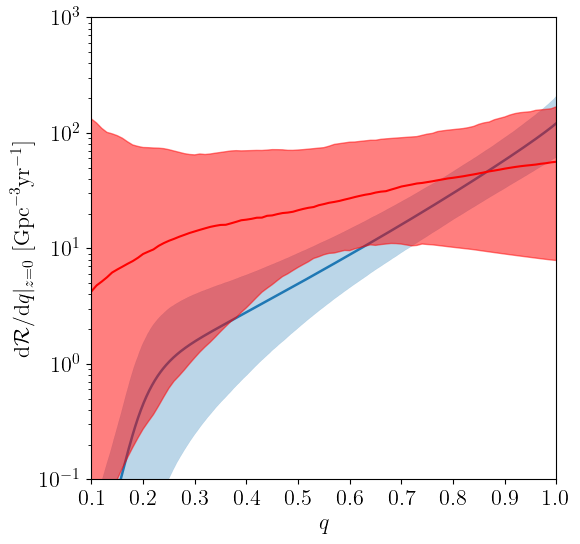

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))

ax.plot(mass_ratio_gwtc3, mass_r_ppd,
        color=color_plpeak, lw=1.8, zorder=1)
ax.fill_between(mass_ratio_gwtc3,
        mass_r_lower,
        mass_r_upper,
        color=color_plpeak, lw=0.2, alpha=0.3, zorder=0)

q_grid = np.linspace(0, 1, 101)
dRdq = np.array([
    simple_massratio_pdf(q_grid, b)
    for b in beta_q
])
dRdq *= dRdz[:,0][:,None]
low_dRdq = np.quantile(dRdq, 0.05, axis=0)
median_dRdq = np.quantile(dRdq, 0.5, axis=0)
high_dRdq = np.quantile(dRdq, 0.95, axis=0)

ax.plot(q_grid, median_dRdq, color="r")
ax.fill_between(q_grid, low_dRdq, high_dRdq,
                color="r", alpha=0.5,
                label=r'Inferred',
                )

ax.set_xlabel(r'$q$')
ax.set_xlim(xmin=0.1, xmax=1)
ax.set_xticks(np.linspace(0.1,1,10))
ax.set_ylabel(r'$\mathrm{d}\mathcal{R}/\mathrm{d}q |_{z=0}\ [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1}]$')
ax.set_yscale('log')
ax.set_ylim(ymin=0.1, ymax=1e3)
# ax.plot(mass_ratio_gwtc3, np.median(dRdq_gwtc3,axis=0),
#         color='r', lw=1.5, zorder=5,
#        )
# ax.fill_between(mass_ratio_gwtc3,
#         np.quantile(dRdq_gwtc3,0.05,axis=0),
#         np.quantile(dRdq_gwtc3, 0.95, axis=0),
#         color='r', alpha=0.3)

plt.show()
plt.close()

# 95% - 5% CI 

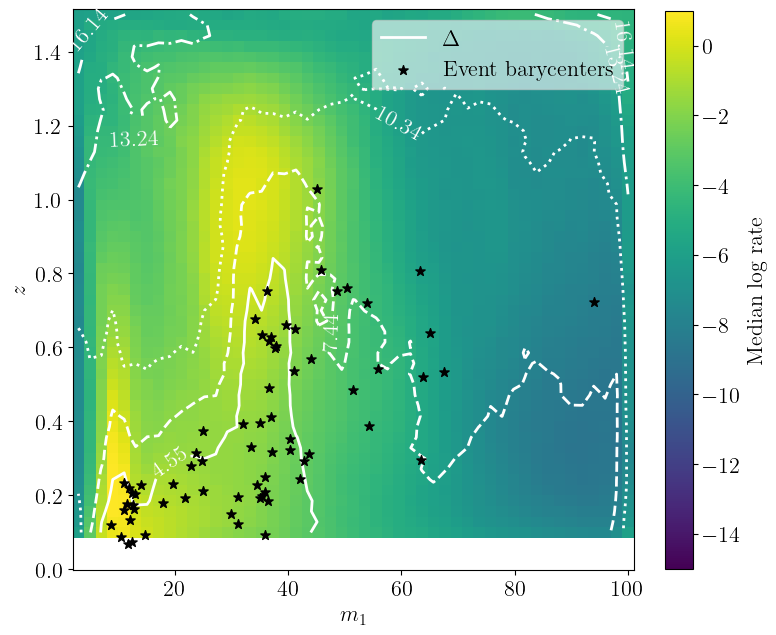

In [31]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize


fig, ax = plt.subplots(figsize=(8,8))
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

c = ax.pcolormesh(m1_grid, z_grid, median +np.log(to_comoving_volume[:,None]),
                 norm=norm,
                 )

# Calculate the difference
diff = high - low

# Define contour levels (choose appropriate values for your data)
n_contours = min(5, len(linestyles))
levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

# Plot contours with different linestyles
contours = ax.contour(
    m1_grid, z_grid, diff, 
    levels=levels, 
    linestyles=linestyles[:n_contours],
    linewidths=2, 
    colors='white'
)
ax.clabel(contours, fmt="%.2f")
ax.plot([],[], c='white', lw=2, label=r'$\Delta$')

ax.scatter(event_barycenters[:,0], event_barycenters[:,1],
           c='k', marker='*', s=7**2, zorder=2,
           label='Event barycenters',
          )

# ax.scatter(detected_injections[:,0], detected_injections[:,1],
#            c='r', marker='d', s=4**2, zorder=1,
#            label='Detected injections',
#           )
ax.set_xlabel('$m_1$')
ax.set_ylabel('$z$')
ax.legend(loc='upper right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(c, ax=ax, fraction=0.045)
cbar.set_label(r'Median log rate')

plt.show()
plt.close()

# Delta

In [32]:
diff = high-low
interp_delta = RegularGridInterpolator((z_grid, m1_grid), diff, bounds_error=False, fill_value=np.nan)

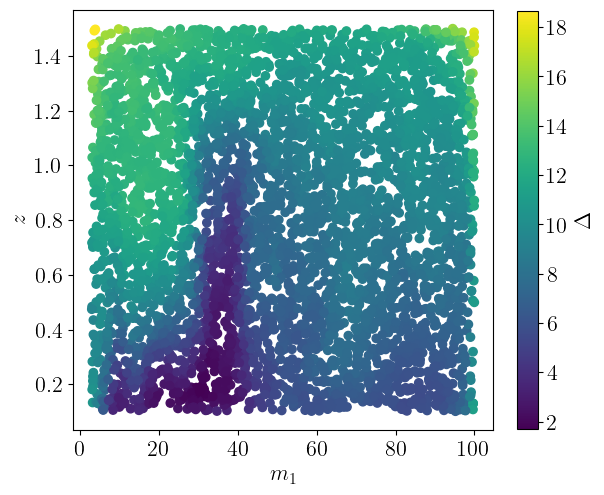

In [33]:
fig,ax=plt.subplots(figsize=(6,6))

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)

sc=ax.scatter(samples_try[:,0],samples_try[:,1],c=interp_delta(samples_try[:,(1,0)]))
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'$\Delta$')

plt.show()
plt.close()

In [34]:
delta_levels = np.linspace(np.min(diff), np.max(diff), 20)[1:-1]
print(delta_levels)

[ 2.56487273  3.47978153  4.39469032  5.30959912  6.22450791  7.13941671
  8.0543255   8.9692343   9.88414309 10.79905189 11.71396068 12.62886948
 13.54377827 14.45868707 15.37359586 16.28850466 17.20341346 18.11832225]


In [35]:
samples_per_tri = 1_000
ndraw = 10_000

ints_delta={}
ints_delta_LVK={}
volume = np.prod(corners.max(axis=0) - corners.min(axis=0))
to_cosmo = interp1d(z_grid, to_comoving_volume, fill_value='extrapolate')
for delta in delta_levels:
    print(delta)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,ndim))
    cosmo_fac=np.zeros(ndraw)

    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,ndim))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)

        nprop+=ndraw-nkeep       
        inds_proposal_keep=np.argwhere(interp_delta(new_points[:,(1,0)])<delta)[:,0]
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        cosmo_fac=to_cosmo(proposals[:,1])
        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_delta[delta]=np.zeros(num_triangulations)
    ints_delta_LVK[delta]=np.zeros(num_pop_LVK)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        #mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        mean_fx = np.mean(np.exp(this_delo.interpolate(proposals)) *cosmo_fac)
        ints_delta[delta][ind] = mean_fx * frac_kept * volume
        
    for ind in tqdm(range(len(selected_pop_LVK))):
        pdf_m1 = interp1d(x=mass_1_gwtc3,  
                          y=dRdm1_gwtc3[ind] /Rz_gwtc3[ind,0], 
                          fill_value="extrapolate")
        rate_z = interp1d(x=zs_gwtc3, 
                          y=Rz_gwtc3[ind], 
                          fill_value="extrapolate")
        mean_Nx = (
            pdf_m1(proposals[:,0])
            *rate_z(proposals[:,1])
        ).mean()       
        ints_delta_LVK[delta][ind] = mean_Nx * frac_kept * volume

2.564872730521552


100%|████████████████████████████████████████| 50/50 [00:00<00:00, 1012.09it/s]


3.4797815258286837


100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 968.76it/s]


4.394690321135816


...

100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 737.82it/s]


17.20341345543567


100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 804.13it/s]


18.1183222507428


100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 798.78it/s]


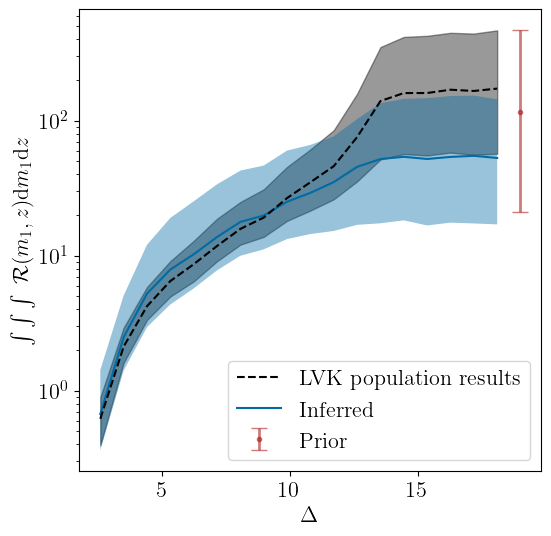

In [36]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = [ np.median(ints_delta_LVK[delta]) for delta in delta_levels]
low_LVK = [ np.quantile(ints_delta_LVK[delta], 0.05) for delta in delta_levels]
high_LVK = [ np.quantile(ints_delta_LVK[delta], 0.95) for delta in delta_levels]
ax.plot(delta_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(delta_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_delta = [ np.median(ints_delta[delta]) for delta in delta_levels]
low_delta = [ np.quantile(ints_delta[delta], 0.05) for delta in delta_levels]
high_delta = [ np.quantile(ints_delta[delta], 0.95) for delta in delta_levels]
ax.plot(delta_levels, median_delta, label='Inferred')
ax.fill_between(delta_levels, low_delta, high_delta, alpha=0.4)

ax.errorbar(delta_levels[-1]*1.05, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

# np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z)\mathrm{d}m_1\mathrm{d}z$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower right')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()

# KL divergences

In [37]:
m1_grid_coarse = np.linspace(m1_min, m1_max, 19)
z_grid_coarse = np.linspace(0.1, z_max, 20)

X_coarse, Y_coarse = np.meshgrid(m1_grid_coarse, z_grid_coarse)
grid_coarse = np.c_[X_coarse.ravel(), Y_coarse.ravel()]

dm1_coarse = m1_grid_coarse[1] - m1_grid_coarse[0]
dz_coarse = z_grid_coarse[1] - z_grid_coarse[0]

to_comoving_volume_coarse = (1 + z_grid_coarse) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_grid_coarse).to(u.Gpc**3 / u.sr).value
    )

In [38]:
log_rate_coarse = np.zeros((num_triangulations, grid_coarse.shape[0]))

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_coarse[ind] = this_delo.interpolate(grid_coarse)
    
square_rate_coarse = log_rate_coarse.reshape(num_triangulations, z_grid_coarse.shape[0], m1_grid_coarse.shape[0])

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 4635.87it/s]


In [39]:
nsamples_prior = 1_000
log_rate_prior_coarse = np.zeros((nsamples_prior, grid_coarse.shape[0]))

for i in tqdm(range(nsamples_prior)):
    nleaves_i = np.random.randint(nvertices_min, nvertices_max)
    tri_i = np.zeros((nleaves_i+offset,ndim+1))
    tri_i[:offset,:-1] = corners
    tri_i[offset:,0] = np.random.uniform(m1_min, m1_max, nleaves_i)
    tri_i[offset:,1] = np.random.uniform(z_min, z_max, nleaves_i)
    tri_i[:,-1] = np.random.uniform(w_min, w_max, nleaves_i+offset)
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior_coarse[i] = this_delo.interpolate(grid_coarse)

square_rate_prior_coarse = log_rate_prior_coarse.reshape(nsamples_prior, z_grid_coarse.shape[0], m1_grid_coarse.shape[0])

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 2414.94it/s]


In [40]:
kl_divs=np.zeros((len(z_grid_coarse),len(m1_grid_coarse)))

for i,j in product(range(z_grid_coarse.shape[0]),range(m1_grid_coarse.shape[0])):
    kl_divs[i,j] = kl_divergence_kde(square_rate_coarse[:,i,j],square_rate_prior_coarse[:,i,j])

In [41]:
interp_kl = RegularGridInterpolator((z_grid_coarse, m1_grid_coarse), kl_divs, bounds_error=False, fill_value=np.nan)

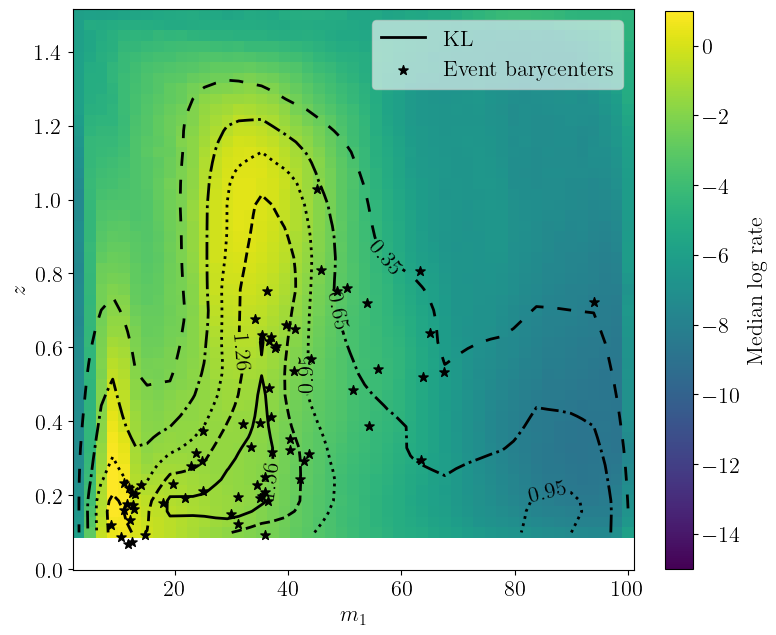

In [42]:

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize
n_contours = min(5, len(linestyles))
levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

fig, ax = plt.subplots(figsize=(8,8))
norm = mpl.colors.Normalize(vmin=-15, vmax=1)

c = ax.pcolormesh(m1_grid, z_grid, median +np.log(to_comoving_volume[:,None]),
                 norm=norm,
                 )

# Calculate the difference
diff = high - low

# Define contour levels (choose appropriate values for your data)
n_contours = min(5, len(linestyles))
levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

# Plot contours with different linestyles
contours_kl = ax.contour(
    m1_grid, z_grid, interp_kl(grid[:,(1,0)]).reshape(len(z_grid),len(m1_grid)), 
    levels=levels_kl, 
    linestyles=linestyles[:n_contours][::-1],
    linewidths=2, 
    colors='black'
)
ax.clabel(contours_kl, fmt="%.2f")
ax.plot([],[], lw=2, color='k', label='KL')

ax.scatter(event_barycenters[:,0], event_barycenters[:,1],
           c='k', marker='*', s=7**2, zorder=2,
           label='Event barycenters',
          )

# ax.scatter(detected_injections[:,0], detected_injections[:,1],
#            c='r', marker='d', s=4**2, zorder=1,
#            label='Detected injections',
#           )
ax.set_xlabel('$m_1$')
ax.set_ylabel('$z$')
ax.legend(loc='upper right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(c, ax=ax, fraction=0.045)
cbar.set_label(r'Median log rate')

plt.show()
plt.close()

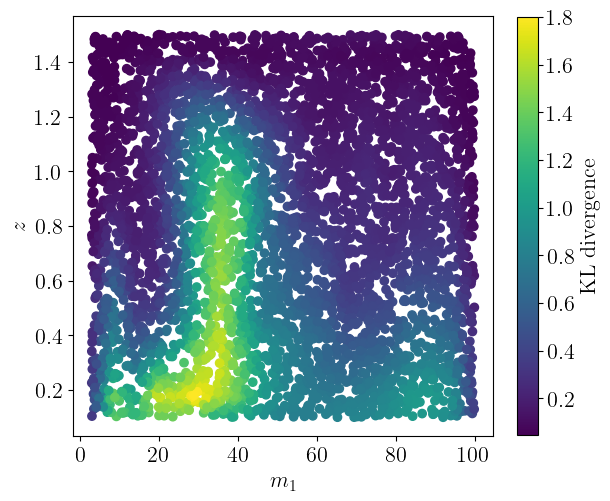

In [43]:
fig,ax=plt.subplots(figsize=(6,6))

samples_try=np.zeros((5000,3))

samples_try[:,0]=np.random.uniform(m1_min,m1_max,5000)
samples_try[:,1]=np.random.uniform(z_min,z_max,5000)

sc=ax.scatter(samples_try[:,0],samples_try[:,1],c=interp_kl(samples_try[:,(1,0)]))
    
ax.set_xlabel(r'$m_1$')
ax.set_ylabel(r'$z$')
#ax.legend(loc='lower right', framealpha=0.6)
ax.set_box_aspect(1)

cbar = fig.colorbar(sc, ax=ax, fraction=0.045)
cbar.set_label(r'KL divergence')

plt.show()
plt.close()

In [44]:
kl_levels = np.linspace(0, np.max(kl_divs), 20)[1:-1]
print(kl_levels)

[0.09799329 0.19598657 0.29397986 0.39197315 0.48996644 0.58795972
 0.68595301 0.7839463  0.88193958 0.97993287 1.07792616 1.17591945
 1.27391273 1.37190602 1.46989931 1.56789259 1.66588588 1.76387917]


In [50]:
samples_per_tri = 1_000
ndraw = 10_000

ints_kl={}
ints_kl_LVK={}
volume = np.prod(corners.max(axis=0) - corners.min(axis=0))
to_cosmo = interp1d(z_grid, to_comoving_volume, fill_value='extrapolate')
for kl in np.flip(kl_levels):
    print(kl)
    nprop=0
    nkeep=0
    nkeep_old=0

    proposals=np.zeros((ndraw,ndim))
    cosmo_fac=np.zeros(ndraw)
    while nkeep<ndraw:
        
        new_points=np.zeros((ndraw-nkeep,ndim))
        new_points[:,0]=np.random.uniform(m1_min,m1_max,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(z_min,z_max,ndraw-nkeep)

        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points[:,(1,0)])>kl)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)
        nkeep+=len(inds_proposal_keep)
        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]
        cosmo_fac=to_cosmo(proposals[:,1])

        nkeep_old+=len(inds_proposal_keep)

    frac_kept = nkeep / nprop

    ints_kl[kl]=np.zeros(num_triangulations)
    ints_kl_LVK[kl]=np.zeros(num_pop_LVK)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        #mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        mean_fx = np.mean(np.exp(this_delo.interpolate(proposals)) *cosmo_fac)        
        ints_kl[kl][ind]= mean_fx * frac_kept * volume

    for ind in tqdm(range(len(selected_pop_LVK))):
        pdf_m1 = interp1d(x=mass_1_gwtc3,  
                          y=dRdm1_gwtc3[ind] /Rz_gwtc3[ind,0], 
                          fill_value="extrapolate")
        rate_z = interp1d(x=zs_gwtc3, 
                          y=Rz_gwtc3[ind], 
                          fill_value="extrapolate")
        mean_Nx = (
            pdf_m1(proposals[:,0])
            *rate_z(proposals[:,1])
        ).mean()       
        ints_kl_LVK[kl][ind] = mean_Nx * frac_kept * volume

1.7638791680709545


100%|████████████████████████████████████████| 50/50 [00:00<00:00, 1402.22it/s]


1.6658858809559014


100%|████████████████████████████████████████| 50/50 [00:00<00:00, 1180.14it/s]


1.5678925938408483


...

100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 843.34it/s]


0.19598657423010604


100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 828.72it/s]


0.09799328711505302


100%|█████████████████████████████████████████| 50/50 [00:00<00:00, 820.15it/s]


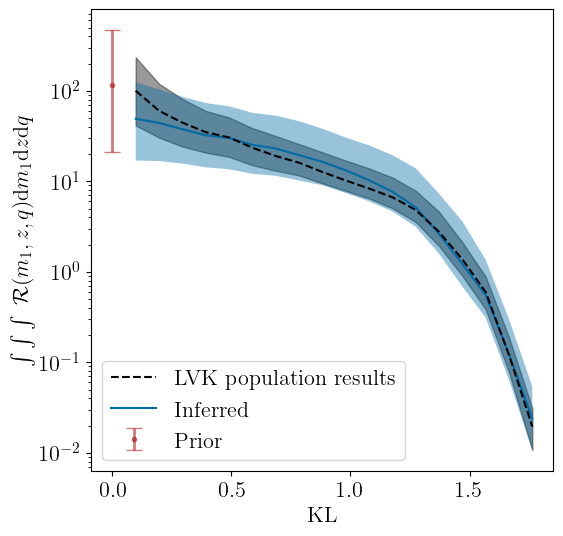

In [51]:
fig, ax = plt.subplots(figsize=(6,6))

median_LVK = [ np.median(ints_kl_LVK[delta]) for delta in kl_levels]
low_LVK = [ np.quantile(ints_kl_LVK[delta], 0.05) for delta in kl_levels]
high_LVK = [ np.quantile(ints_kl_LVK[delta], 0.95) for delta in kl_levels]

ax.plot(kl_levels, median_LVK, "--", color="black", zorder=3, label="LVK population results")
ax.fill_between(kl_levels, low_LVK, high_LVK, 
                alpha=0.4, color="black")

median_kl = [ np.median(ints_kl[kl]) for kl  in kl_levels]
low_kl = [ np.quantile(ints_kl[kl], 0.05) for kl  in kl_levels]
high_kl = [ np.quantile(ints_kl[kl], 0.95) for kl  in kl_levels]

ax.plot(kl_levels, median_kl, label='Inferred')
ax.fill_between(kl_levels, low_kl, high_kl, alpha=0.4)

ax.errorbar(0, median_prior, np.array([[median_prior-low_prior,high_prior-median_prior]]).T,
            color='firebrick', alpha=0.6, linewidth=2, capsize=6, fmt='.',
            label="Prior",
           )

ax.set_xlabel(r'KL')
ax.set_ylabel(r'$\int\int\int\ \mathcal{R}(m_1,z,q)\mathrm{d}m_1\mathrm{d}z\mathrm{d}q$')
ax.set_yscale('log')
#ax.set_ylim(ymin=1e1, ymax=1e5)

ax.legend(loc='lower left')
ax.set_box_aspect(1)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()